In [1]:
import pandas as pd

In [2]:
thoracic_gen_models.tabsyn = pd.read_csv('synthetic/thoracic_surgery/gen_models.tabsyn.csv')
thoracic_ganos = pd.read_csv('synthetic/thoracic_surgery/ganos.csv')
thoracic_codi = pd.read_csv('synthetic/thoracic_surgery/codi.csv')
thoracic_findiff = pd.read_csv('synthetic/thoracic_surgery/findiff.csv')
thoracic_great = pd.read_csv('synthetic/thoracic_surgery/great.csv')
thoracic_ctgan = pd.read_csv('synthetic/thoracic_surgery/ctgan.csv')
thoracic_smote = pd.read_csv('synthetic/thoracic_surgery/smote.csv')

models = ["gen_models.tabsyn", "ganos", "codi", "ctgan"]

datasets = [thoracic_gen_models.tabsyn, thoracic_ganos, thoracic_codi, thoracic_ctgan]

# original data

thoracic = pd.read_csv('data/thoracic_surgery/train.csv')

In [3]:
thoracic

,PRE4,PRE5,PRE6,PRE7,PRE8,PRE9,PRE10,PRE11,PRE14,PRE17,...,PRE30,PRE32,AGE,DGN_DGN2,DGN_DGN3,DGN_DGN4,DGN_DGN5,DGN_DGN6,DGN_DGN8,Risk1Yr
0,2.04,1.80,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,64.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,3.24,2.40,1.0,1.0,1.0,0.0,0.0,0.0,3.0,0.0,...,1.0,0.0,55.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,2.40,1.24,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,62.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,2.40,1.64,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,64.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,3.20,2.52,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,...,1.0,0.0,75.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405,3.68,3.20,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,55.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
406,3.24,1.64,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,63.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
407,5.00,4.04,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,60.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
408,2.58,1.64,2.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,...,1.0,0.0,63.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
thoracic_ganos.Risk1Yr.value_counts()

0.0    349
1.0     61
Name: Risk1Yr, dtype: int64

In [5]:
data = pd.read_csv('/home/pcrespo/awesome-tab-augmentation/gen_models/ganos/thoracic_surgery/synthetic_balanced.csv')

In [11]:
data['Risk1Yr'].value_counts()

0.0    349
1.0    349
Name: Risk1Yr, dtype: int64

In [15]:
alpha_precissions = {}
beta_recalls = {}
klds = {}
hds = {}
maeps = {}
pcds = {}
lcms = {}


thoracic_df = pd.DataFrame(columns=["Alpha Precission", "Beta Recall", "KLD", "HD", "MAEP", "PCD", "LCM"])
for model in models:
    quality_path = "eval/quality/thoracic_surgery/" + model + ".txt"
    with open(quality_path, "r") as f:
        lines = f.readlines()
        
        for line in lines:
            if "Alpha" in line:
                alpha_precision = float(line.split(":")[1].strip())
            
            if "Beta" in line:
                beta_recall = float(line.split(":")[1].strip())
                
            if "KLD" in line:
                kld = float(line.split(":")[1].strip())
                
            if "HD" in line:
                hd = float(line.split(":")[1].strip())
            
            if "MAEP" in line:
                maep = float(line.split(":")[1].strip())
                
            if "PCD" in line:
                pcd = float(line.split(":")[1].strip())
            
            if "LCM" in line:
                lcm = float(line.split(":")[1].strip())
            
    alpha_precissions[model] = alpha_precision
    beta_recalls[model] = beta_recall
    klds[model] = kld
    hds[model] = hd
    maeps[model] = maep
    pcds[model] = pcd
    lcms[model] = lcm

for model in models:
    thoracic_df.loc[model] = [alpha_precissions[model], beta_recalls[model], klds[model], hds[model], maeps[model], pcds[model], lcms[model]]

thoracic_df

,Alpha Precission,Beta Recall,KLD,HD,MAEP,PCD,LCM
gen_models.tabsyn,0.909919,0.573984,0.196013,0.153900,0.107766,0.056186,-5.622678
ganos,0.901923,0.144715,3.409029,0.491086,0.860850,1.737603,-3.411910
codi,0.610407,0.440976,1.730888,0.363486,0.370117,0.234148,-5.266788
ctgan,0.778211,0.106829,2.867902,0.403673,0.659213,1.423827,-8.761242


In [10]:
shape_scores = {}
trend_scores = {}

thoracic_df = pd.DataFrame(columns=["Shape Score", "Trend Score"])

for model in models:
    quality_path = "eval/density/thoracic_surgery/" + model + "/quality.txt"
    with open(quality_path, "r") as f:
        lines = f.readlines()
        
        alpha_precission = float(lines[0].split(":")[1].strip())
        beta_recall = float(lines[1].split(":")[1].strip())
        
        alpha_precissions[model] = alpha_precission
        beta_recalls[model] = beta_recall

for model in models:
    thoracic_df.loc[model] = [alpha_precissions[model], beta_recalls[model]]

thoracic_df

FileNotFoundError: [Errno 2] No such file or directory: 'eval/density/thoracic_surgery/smote/quality.txt'

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_variable_distributions(dataset1, dataset2, var_list, dataset1_label='Dataset 1', dataset2_label='Dataset 2'):
    """
    Superpone las distribuciones de las variables de dos datasets con las mismas variables.
    
    Args:
        dataset1 (DataFrame): Primer conjunto de datos.
        dataset2 (DataFrame): Segundo conjunto de datos.
        var_list (list): Lista de nombres de las variables que se desean graficar.
        dataset1_label (str): Etiqueta para el primer dataset.
        dataset2_label (str): Etiqueta para el segundo dataset.
    
    Returns:
        None: La función genera los gráficos.
    """
    num_vars = len(var_list)
    fig, axes = plt.subplots(1, num_vars, figsize=(6 * num_vars, 4), sharey=False)
    
    for i, var in enumerate(var_list):
        ax = axes[i] if num_vars > 1 else axes
        sns.kdeplot(dataset1[var], ax=ax, label=dataset1_label, linewidth=2, color='blue', fill=True, alpha=0.3)
        sns.kdeplot(dataset2[var], ax=ax, label=dataset2_label, linewidth=2, color='orange', fill=True, alpha=0.3)
        ax.set_title(var, fontsize=12)
        ax.set_xlabel(var, fontsize=10)
        ax.set_ylabel("Density", fontsize=10)
        ax.legend()
    
    plt.tight_layout()
    plt.show()


In [8]:
thoracic

,PRE4,PRE5,PRE6,PRE7,PRE8,PRE9,PRE10,PRE11,PRE14,PRE17,...,PRE30,PRE32,AGE,DGN_DGN2,DGN_DGN3,DGN_DGN4,DGN_DGN5,DGN_DGN6,DGN_DGN8,Risk1Yr
0,2.04,1.80,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,64.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,3.24,2.40,1.0,1.0,1.0,0.0,0.0,0.0,3.0,0.0,...,1.0,0.0,55.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,2.40,1.24,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,62.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,2.40,1.64,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,64.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,3.20,2.52,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,...,1.0,0.0,75.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405,3.68,3.20,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,55.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
406,3.24,1.64,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,63.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
407,5.00,4.04,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,60.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
408,2.58,1.64,2.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,...,1.0,0.0,63.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


Comparing gen_models.tabsyn with real data


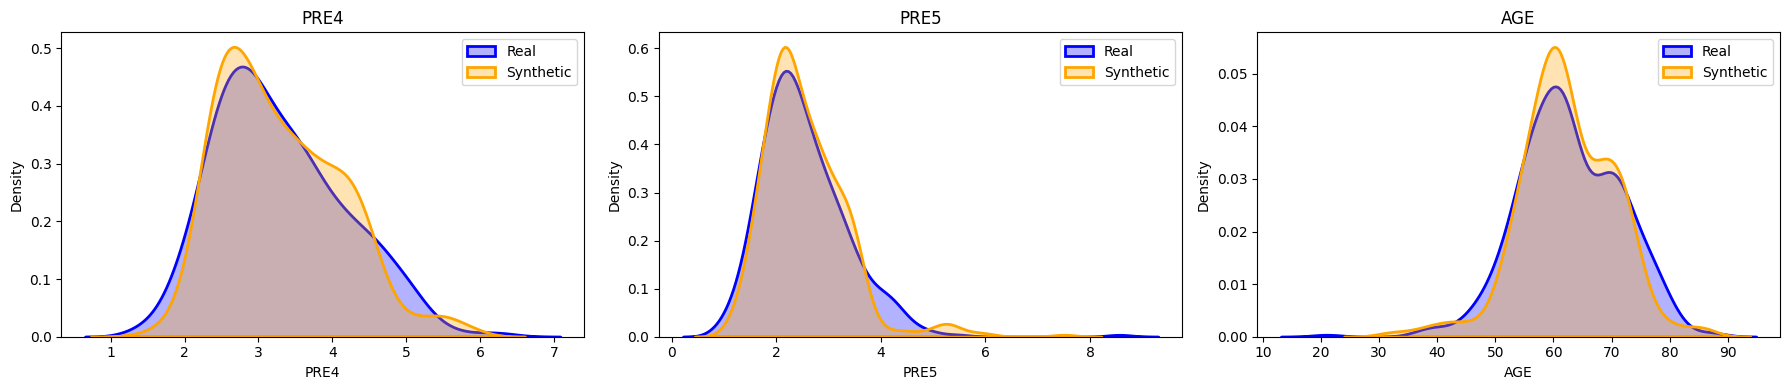

Comparing ganos with real data


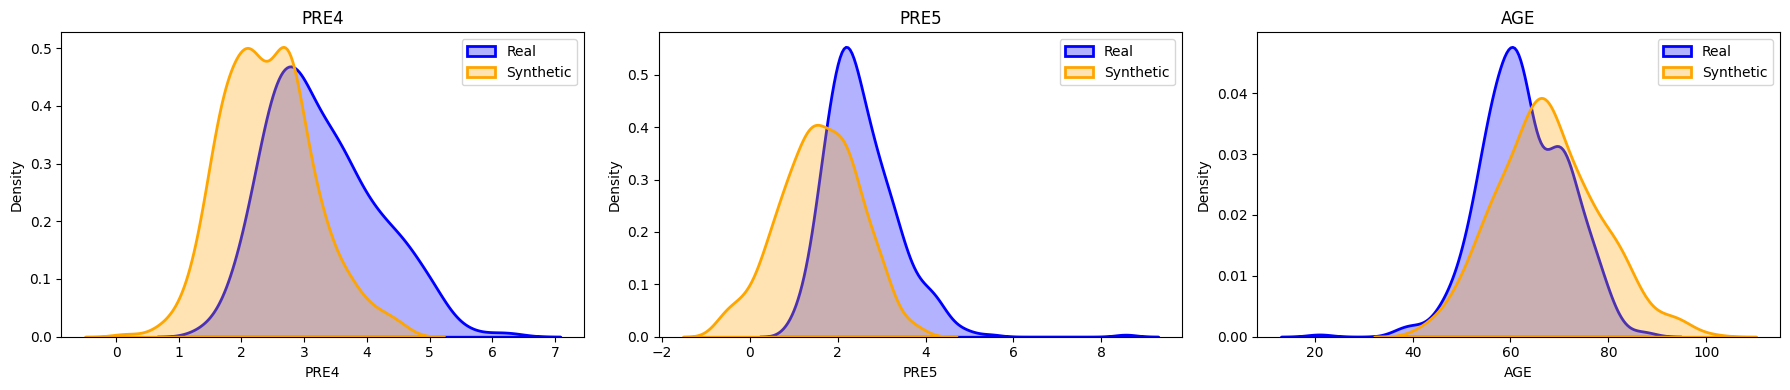

Comparing codi with real data


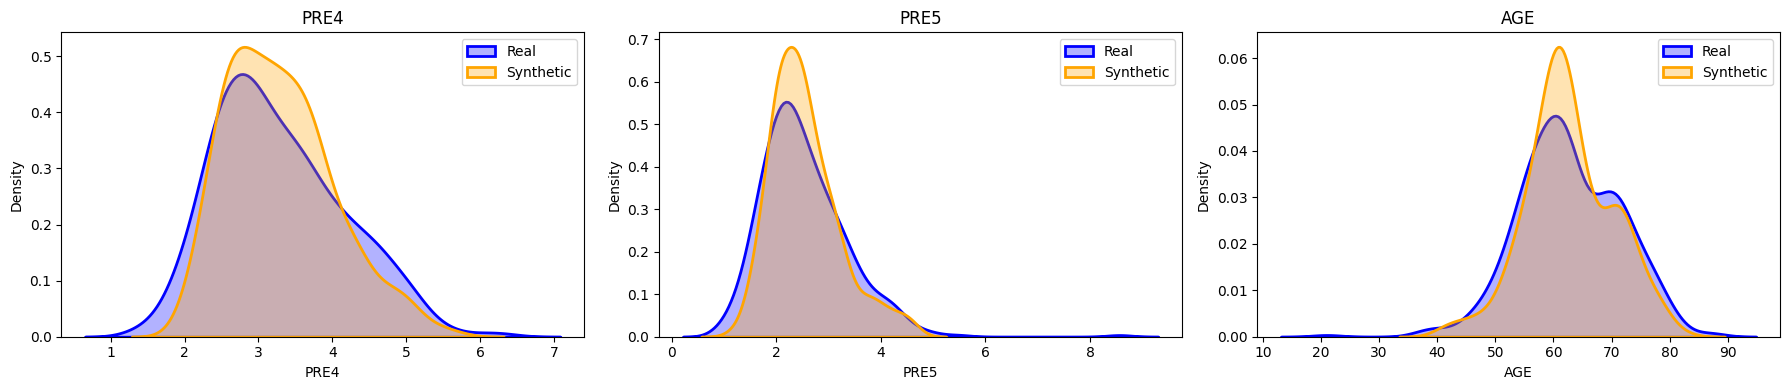

Comparing ctgan with real data


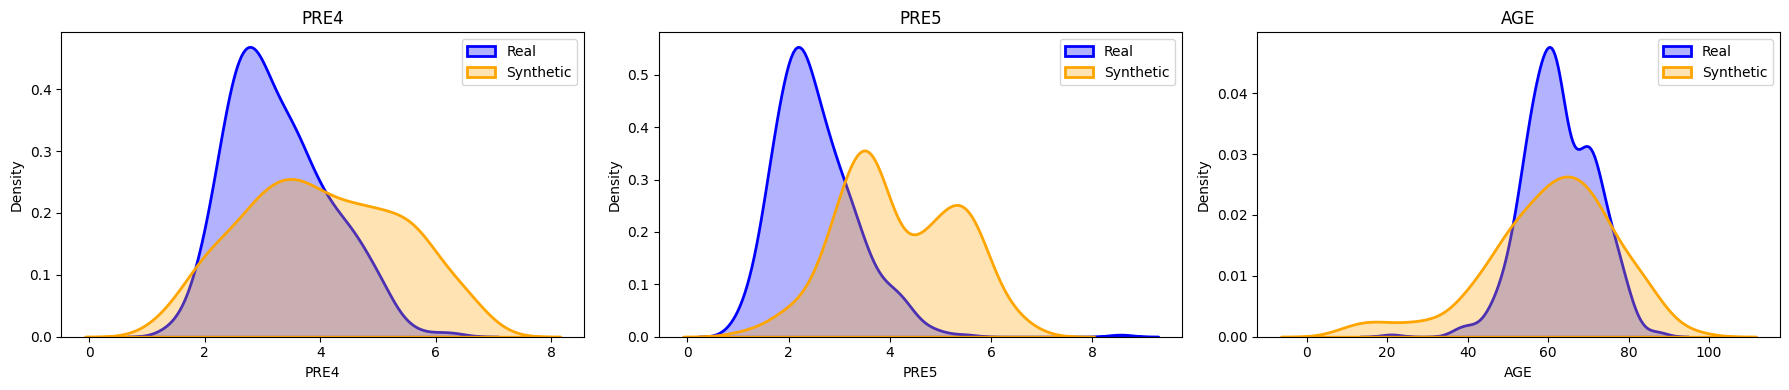

Comparing smote with real data


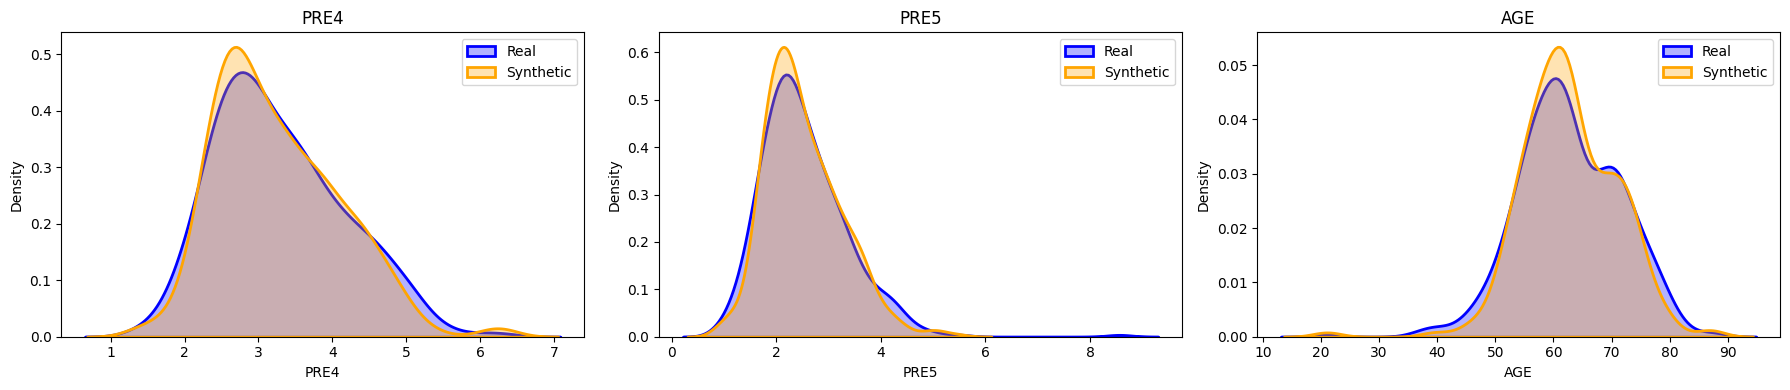

In [28]:
var_list = ['PRE4', 'PRE5', 'AGE']

for model in models:
    dataset = datasets[models.index(model)]
    print(f"Comparing {model} with real data")
    plot_variable_distributions(thoracic, dataset, var_list=var_list,
                                dataset1_label='Real', dataset2_label='Synthetic')

In [10]:
def process_results(lines):
    """
    Process lines of text into a dictionary of metric results.

    Args:
        lines (list of str): Lines read from the file.

    Returns:
        dict: Dictionary with metrics as keys and their values.
    """
    results = {}
    current_key = None

    for line in lines:
        line = line.strip()
        if line.endswith(":"):  # Detect metric name
            current_key = line[:-1]
            results[current_key] = ""  # Initialize the value for this key
        elif current_key:  # Accumulate values for the current key
            results[current_key] += line + " "

    # Parse the accumulated values into Python objects if possible
    for key, value in results.items():
        try:
            results[key] = eval(value.strip())  # Safely parse the value
        except:
            results[key] = value.strip()  # Keep as string if parsing fails

    return results

In [11]:
metrics_all = {}

for model in models:
    quality_path = "eval/metrics/thoracic_surgery/" + model + "/metrics.txt"
    with open(quality_path, "r") as f:
        lines = f.readlines()
        results = process_results(lines)

        metrics_all[model] = results

In [12]:
df_metrics = pd.DataFrame.from_dict(metrics_all, orient="index")


In [13]:
df_metrics

,Kolmogorov-Smirnov Test,Total Variation Distance,Kullback-Leibler Divergence,Hellinger Distance,Mean Absolute Error Probability,Pairwise Correlation Difference
gen_models.tabsyn,"{2: {'statistic': 0.041463414634146344, 'p_val...","{2: 0.05609756097560973, 3: 0.0097560975609755...","{2: 0.007877651011388006, 3: 0.000832840750850...","{2: 0.04435995323462588, 3: 0.0144258618956954...","{2: 0.11219512195121946, 3: 0.0195121951219511...",0 0.067310 1 0.035596 14 0.034324 d...
ganos,"{2: {'statistic': 0.04390243902439024, 'p_valu...","{2: 0.043902439024390255, 3: 0.034146341463414...","{2: 0.0153229907556629, 3: 0.00776784102653821...","{2: 0.06174118358371346, 3: 0.0439943372794397...","{2: 0.08780487804878051, 3: 0.0682926829268293...",0 0.394327 1 0.532106 14 0.504032 d...
codi,"{2: {'statistic': 0.11707317073170732, 'p_valu...","{2: 0.11707317073170734, 3: 0.0634146341463414...","{2: 0.5888322861709189, 3: 0.02361415930325461...","{2: 0.1843391870518889, 3: 0.07650742455866216...","{2: 0.23414634146341468, 3: 0.1268292682926829...",0 0.172132 1 0.193851 14 0.202433 d...
ctgan,"{2: {'statistic': 0.05853658536585366, 'p_valu...","{2: 0.05853658536585363, 3: 0.0414634146341463...","{2: 0.011073985346502483, 3: 0.011065640491200...","{2: 0.05258321604900408, 3: 0.0524776025707720...","{2: 0.11707317073170725, 3: 0.0829268292682927...",0 1.187538 1 1.090680 14 0.549633 d...
